# 035 — GM record selection, AvgSA([0, 6]) — Stage 1 (compute)

The slow selection step. Runs the configurable multi-round selection + optimisation engine
(`build_final_ensembles`) to build the final per-`(site, poe)` record ensembles conditioned on
**AvgSA([0, 6])**. Round 2 uses a dict spec (`{"select": ["d"], "optimise": ["d", "vs30"]}`) so
reselection drops only the distance bound while optimisation drops distance + vs30 — reproducing
the legacy AvgSA_06 scheme. **Round 4** is a last-ditch retry: for any `(site, poe)` still failing
after round 3 it re-runs the optimisation over `n_shuffles` shuffled database orderings
(`shuffle = [False, False, False, True]`) and keeps the best-scoring ensemble — a shuffled result
only replaces the incumbent if it passes or scores strictly better, so round 4 can never make a set
worse. First run can take ~an hour; every stage is provenance-cached so re-runs are near-instant.

Each round prints a two-phase summary — a **selection** phase (only sites without a record set yet)
and an **optimisation** phase — labelling the causal bounds as `[bounded: … | unbounded: …]` and
explaining what the work-set of each phase contains (freshly (re)selected vs. carried-over failing
sets, and how many still have no record set at all).

**Upstream**:

| Input | Source |
|---|---|
| GCIM target distributions | `gcim_dist_AvgSA_06.pickle` (nb `034`) |
| Combined selection GM database | `cfg["proc_data"]["gm_database"]` |
| IML-based disaggregations + poe stats | `cfg["proc_data"]["AvgSA_06_disagg_data_gm_selection"]`, `cfg["proc_data"]["AvgSA_06_disagg_stats_gm_selection"]` |
| Site model | `cfg["hazard_models"]["eshm20_wp1_site_model"]` |
| GMM logic tree + correlation flatfiles | loaded inside `setup_AvgSA06_gcim_gm_selection()` |

**Downstream** — `036-gm_selection_AvgSA_06_stage2_postprocess.ipynb` (the fast post-processing
notebook) consumes the canonical `AvgSA_06_final_ensembles.pickle` and re-verifies its manifest.

**Output** (all under `cfg["proc_data"]["gm_selection"]`):
- `AvgSA_06_final_ensembles.pickle` + `.manifest.json` — canonical artifact.
- Per-round stage caches (`AvgSA_06_prelim_selection.pickle`, `..._optimised_selection_rd0N.pickle`,
  …), each provenance-guarded via its own `.manifest.json`.

**Run order** — run top to bottom. Each stage is provenance-cached: if an input (gm_db, gcim
distributions, disagg, site model, params, `rng_seed`, `pickagm` version, round config) changed
since the cache was written it is recomputed automatically; unchanged stages print
`[cache] ... loaded`. Set `FORCE_RECOMPUTE = True` to rebuild every stage + the final artifact. - Slow (several hours)

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pickle
import numpy as np
import pandas as pd

from phd_project.config.config import load_config
from phd_project.scripts.WP1_ground_motion_set.gm_selection import build_final_ensembles
from phd_project.scripts.WP1_ground_motion_set.setup_AvgSA06_gm_selection import setup_AvgSA06_gcim_gm_selection


cfg = load_config()

C:\Users\clemettn\Documents\phd\phd_project\scripts\WP1_ground_motion_set\gm_selection.py:15: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [ ]:
# canonical Stage-1 output (consumed by the post-processing notebook)
final_ensembles_fp = cfg["proc_data"]["gm_selection"] / "AvgSA_06_final_ensembles.pickle"

# intermediate stage caches, one per round (provenance-guarded)
GMS = cfg["proc_data"]["gm_selection"]
stage_fps = {
    "select": [
        GMS / "AvgSA_06_prelim_selection.pickle",        # round 1 selection (all sites)
        GMS / "AvgSA_06_prelim_reselection.pickle",      # round 2 reselection (no-set sites)
        GMS / "AvgSA_06_prelim_reselection_rd03.pickle", # round 3 reselection (usually none)
        GMS / "AvgSA_06_prelim_reselection_rd04.pickle", # round 4 reselection (usually none)
    ],
    "optimise": [
        GMS / "AvgSA_06_optimised_selection_rd01.pickle",  # round 1 optimise
        GMS / "AvgSA_06_optimised_selection_rd02.pickle",  # round 2 optimise
        GMS / "AvgSA_06_optimised_selection_rd03.pickle",  # round 3 optimise
        GMS / "AvgSA_06_optimised_selection_rd04.pickle",  # round 4 optimise (shuffled)
    ],
}

# inputs used for provenance fingerprinting (hashed by their file bytes)
gcim_dist_fp = cfg["proc_data"]["gcim_dists"] / "gcim_dist_AvgSA_06.pickle"
source_fps = {
    "gm_db_file":        cfg["proc_data"]["gm_database"],
    "gcim_file":         gcim_dist_fp,
    "disagg_data_file":  cfg["proc_data"]["AvgSA_06_disagg_data_gm_selection"],
    "disagg_stats_file": cfg["proc_data"]["AvgSA_06_disagg_stats_gm_selection"],
    "site_model_file":   cfg["hazard_models"]["eshm20_wp1_site_model"],
}

# Selection scheme: 4 rounds, dropping progressively more causal-parameter bounds.
round_unbounded = [
    [],                                            # round 1: all of m, d, vs30 bounded
    ["d"],                                         # round 2: d+vs30-free
    ["m", "d", "vs30"],                            # round 3: drop all bounds
    ["m", "d", "vs30"],                            # round 4: all bounds free again + shuffled-DB retry
]

# Per round: optimise the whole round work-set (True) or only sites still failing
# after that round's selection (False). round 2 force-re-optimises the reselected
# sites; rounds 3-4 only touch what is still failing.
force_optimisation = [False, False, False, False]

# Per round: re-run the optimisation over several shuffled database orderings and
# keep the best-scoring ensemble per (site, poe). Round 4 is a last-ditch retry for
# the sets still failing after round 3 - the greedy optimiser is order-dependent, so
# shuffling can escape a bad local optimum. A shuffled result only replaces the
# incumbent if it passes or scores strictly better (never a regression).
shuffle = [False, False, False, True]
n_shuffles = 5                       # number of shuffled orderings tried in round 4
shuffle_rng_seeds = [1, 2, 3, 4, 5]  # one seed per shuffle

# other stuff:
rng_seed = 1

# Set True to rebuild every stage + the final artifact, ignoring (and overwriting)
# any existing cache. Leave False for normal runs: an input change then raises
# StaleCacheError instead of silently reusing stale results.
FORCE_RECOMPUTE = False

In [4]:
# set up the record selection
site_poe_disaggs, disagg_stats, site_model, basic_selection_ctx, gm_db = setup_AvgSA06_gcim_gm_selection()

# load the gcim distributions
if gcim_dist_fp.is_file():
    with open(gcim_dist_fp, "rb") as file:
        gcim_dists = pickle.load(file)
    print("Existing GCIM distribution data loaded...")
else:
    print("No existing GCIM distribution data found...")

Built 327 (site, poe) disaggregations across 60 sites.
Existing GCIM distribution data loaded...


## Stage 1 - Build final ensembles (slow compute)

Runs the configurable multi-round selection + optimisation engine and saves the canonical
`AvgSA_06_final_ensembles.pickle` (+ a `.manifest.json` provenance sidecar). Round 2
uses a dict spec so reselection drops only the distance bound while optimisation drops
distance + vs30 - reproducing the legacy AvgSA_06 scheme. **Round 4** re-optimises any
`(site, poe)` still failing after round 3 over `n_shuffles = 5` shuffled database orderings and
keeps the best-scoring ensemble per `(site, poe)` (replaced only if it passes or scores strictly
better). Each step is provenance-cached (changed inputs are recomputed automatically;
`FORCE_RECOMPUTE = True` to rebuild). Each round prints a `[bounded: … | unbounded: …]` bounds
label plus a selection-phase and optimisation-phase breakdown; cached stages print
`[cache] ... loaded`.

Post-processing lives in **`036-gm_selection_AvgSA_06_stage2_postprocess.ipynb`**.

In [5]:
final_ensembles = build_final_ensembles(
    site_poe_disaggs,
    disagg_stats,
    gcim_dists,
    gm_db,
    basic_selection_ctx,
    site_model,
    source_fps=source_fps,
    stage_fps=stage_fps,
    output_fp=final_ensembles_fp,
    round_unbounded=round_unbounded,
    force_optimisation=force_optimisation,
    shuffle=shuffle,
    n_shuffles=n_shuffles,
    shuffle_rng_seeds=shuffle_rng_seeds,
    rng_seed=rng_seed,
    force_recompute=FORCE_RECOMPUTE,
)


================ Round 1/4 ================
Bounds  [bounded: m, d, vs30 | unbounded: none]
Selection phase — all 327 (site, poe) [first round]
[cache] 'AvgSA_06_prelim_selection.pickle' loaded (inputs match).
    -> 86 pass, 241 fail KS  (of which 33 could not form a record set at all)
Optimisation phase — 241 (site, poe)  [only sites still failing]
    (33 of these still have no record set -> skipped by the optimiser)
[cache] 'AvgSA_06_optimised_selection_rd01.pickle' loaded (inputs match).
    -> 85 now pass, 156 still fail
-> 156 (site, poe) carried into the next round

================ Round 2/4 ================
Bounds  select [bounded: m, vs30 | unbounded: d]  optimise [bounded: m | unbounded: d, vs30]
Selection phase — reselecting 33 (site, poe) that had no record set after round 1
[cache] 'AvgSA_06_prelim_reselection.pickle' loaded (inputs match).
    -> 0 pass, 33 fail KS  (of which 1 could not form a record set at all)
Optimisation phase — 155 (site, poe)  [force: all still-

Shuffle 1 - Optimising Ensemble:   0%|          | 0/8 [00:00<?, ?it/s]

Optimizing Ensemble Slots:   0%|          | 0/30 [00:00<?, ?it/s]

Optimizing Ensemble Slots:   0%|          | 0/30 [00:00<?, ?it/s]

Optimizing Ensemble Slots:   0%|          | 0/30 [00:00<?, ?it/s]

...

Optimizing Ensemble Slots:   0%|          | 0/30 [00:00<?, ?it/s]

Optimizing Ensemble Slots:   0%|          | 0/30 [00:00<?, ?it/s]

Optimizing Ensemble Slots:   0%|          | 0/30 [00:00<?, ?it/s]

Optimizing Ensemble Slots:   0%|          | 0/30 [00:00<?, ?it/s]

    -> 0 now pass, 8 still fail
      (keep-best: replaced 6, kept incumbent for 2)
-> 8 (site, poe) carried into the next round

Sub-Optimal! - 8 (site, poe) still without a passing ensemble after 4 rounds


In [6]:
failing = {k:v for k, v in final_ensembles.items() if not v["ks_passed"]}
fks = list(failing.keys())

In [7]:
# Isolate the (site, poe) that still fail the KS test after all rounds, mapping
# each to its list of failing IMs. Not pickled - just a quick look at the residual.
failing_ensembles = {
    k: v["ks_failed_ims"]
    for k, v in final_ensembles.items()
    if not v["ks_passed"]
}

print(f"{len(failing_ensembles)} (site, poe) still failing:")
for k in failing_ensembles:
    print("  ", k, "->", failing_ensembles[k])

8 (site, poe) still failing:
   (4, 1.9900787929794106e-06) -> ['PGA', 'SA(0.025)', 'SA(0.033)', 'SA(0.045)', 'SA(6.0)']
   (4, 9.323305854014308e-07) -> ['PGA', 'SA(0.025)', 'SA(0.033)', 'SA(0.045)', 'SA(0.059)', 'SA(0.079)', 'SA(0.597)', 'SA(6.0)']
   (4, 3.046355327995798e-07) -> ['RSD595', 'PGA', 'SA(0.025)', 'SA(0.033)', 'SA(0.045)', 'SA(0.059)', 'SA(0.079)', 'SA(0.106)', 'SA(0.447)', 'SA(0.597)', 'SA(6.0)']
   (4, 1.0334775102371907e-07) -> ['RSD595', 'PGA', 'SA(0.025)', 'SA(0.033)', 'SA(0.045)', 'SA(0.059)', 'SA(0.079)', 'SA(0.106)', 'SA(0.141)', 'SA(0.447)', 'SA(0.597)', 'SA(6.0)']
   (23, 1.6554299169024844e-05) -> ['RSD595']
   (51, 2.46272911286205e-07) -> ['RSD595', 'PGA']
   (53, 2.6091531867278306e-06) -> ['SA(6.0)']
   (57, 1.533296772227022e-05) -> ['SA(6.0)']


In [8]:
failing[fks[0]].keys()

dict_keys(['recs', 'ks_passed', 'ks_results', 'ks_failed_ims', 'ks_bounds', 'ecdfs', 'quantiles', 'mu_lnIM_recs', 'sig_lnIM_recs', 'cond_imt', 'cond_iml'])

In [9]:
failing[fks[1]]["ks_failed_ims"]

['PGA',
 'SA(0.025)',
 'SA(0.033)',
 'SA(0.045)',
 'SA(0.059)',
 'SA(0.079)',
 'SA(0.597)',
 'SA(6.0)']

['RSD595', 'PGA', 'SA(0.025)', 'SA(0.033)', 'SA(0.045)', 'SA(0.059)', 'SA(0.079)', 'SA(0.106)', 'SA(0.447)', 'SA(0.597)', 'SA(6.0)']


(0.0, 1.0)

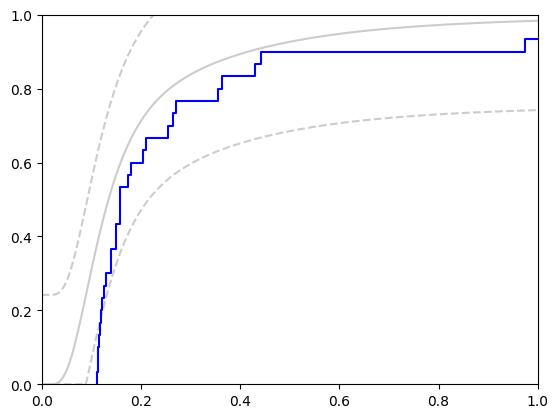

In [14]:
import matplotlib.pyplot as plt
from phd_project.plotting.plotting import plot_im_ecdf_vs_target

idx = 2
im = "PGA"

print(failing[fks[idx]]["ks_failed_ims"])
site_poe = fks[idx]
ecdf = failing[site_poe]["ecdfs"][im]
ks_bounds = failing[site_poe]["ks_bounds"][im]

fig, ax = plt.subplots()

ax = plot_im_ecdf_vs_target(ax, ecdf, ks_bounds)
ax.set_xlim(0, 1)